Imports & Settings

In [1]:
import pandas as pd
import re
import numpy as np 

pd.options.display.float_format = '{:.2f}'.format 

Import Datasets

In [2]:
# Importing both datasets
df1 = pd.read_csv("airlines_review.csv")
df2 = pd.read_csv("airlines_reviews.csv")

**NOTE: DATA UNDERSTANDING WILL HAVE BEFORE AND AFTER PREPROCESSING AS DIFFERENT SEPARATE PHASES**

**PHASE 1: DATA UNDERSTANDING (BEFORE PREPROCESSING)**

=== INSPECTING DATASET 1 (airlines_review.csv) ===

[1] DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13590 entries, 0 to 13589
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Airlines                13590 non-null  object 
 1   Name                    13590 non-null  object 
 2   Location                13590 non-null  int64  
 3   Date Published          13590 non-null  object 
 4   Text Content            13590 non-null  object 
 5   Seat Type               13590 non-null  object 
 6   Seat Comfort            3123 non-null   float64
 7   Cabin Staff Service     3124 non-null   float64
 8   Food & Beverages        3154 non-null   float64
 9   Inflight Entertainment  6749 non-null   float64
 10  Value For Money         10904 non-null  float64
 11  Recommended             10904 non-null  object 
 12  Ground Service          9610 non-null   float64
 13  Wifi & Connectivity  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Airlines,13590,6,british_airways,3841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,13590,10188,Anders Pedersen,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,13590.00,NaN,NaN,NaN,2017.59,3.10,2011.00,2015.00,2017.00,2019.00,2024.00
Date Published,13590,3322,2015-01-19,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Text Content,13590,13459,We flew indirect to Orlando and back - althoug...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seat Type,13590,895,Economy Class,1860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seat Comfort,3123.00,NaN,NaN,NaN,3.50,1.28,1.00,3.00,4.00,5.00,5.00
Cabin Staff Service,3124.00,NaN,NaN,NaN,3.71,1.44,0.00,3.00,4.00,5.00,5.00
Food & Beverages,3154.00,NaN,NaN,NaN,3.41,1.40,0.00,2.00,4.00,5.00,5.00
Inflight Entertainment,6749.00,NaN,NaN,NaN,3.05,1.49,0.00,2.00,3.00,4.00,5.00


None

[3] PLOTTING RAW DATA...


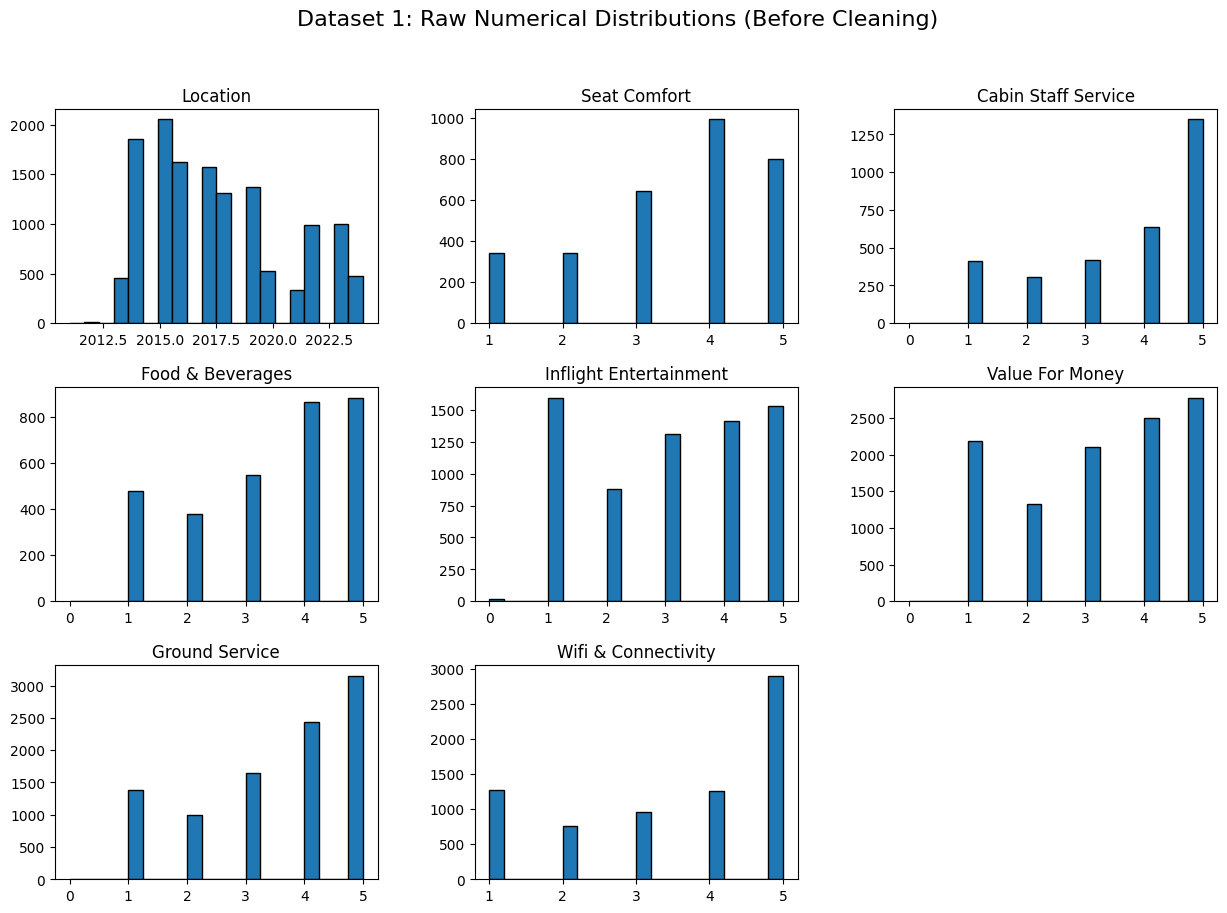



=== INSPECTING DATASET 2 (airlines_reviews.csv) ===

[1] DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Title                   8100 non-null   object
 1   Name                    8100 non-null   object
 2   Review Date             8100 non-null   object
 3   Airline                 8100 non-null   object
 4   Verified                8100 non-null   object
 5   Reviews                 8100 non-null   object
 6   Type of Traveller       8100 non-null   object
 7   Month Flown             8100 non-null   object
 8   Route                   8100 non-null   object
 9   Class                   8100 non-null   object
 10  Seat Comfort            8100 non-null   int64 
 11  Staff Service           8100 non-null   int64 
 12  Food & Beverages        8100 non-null   int64 
 13  Inflight Entertainment  8100 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Title,8100,7614,Turkish Airlines customer review,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,8100,6583,Michael Schade,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Date,8100,2549,12/18/2017,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airline,8100,10,Turkish Airlines,1685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Verified,8100,5,TRUE,6216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviews,8100,8099,Unforgettable experience flying with Emirates...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of Traveller,8100,4,Solo Leisure,3237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month Flown,8100,107,Nov-17,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Route,8100,5566,Bangkok to Hong Kong,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,8100,4,Economy Class,5504,NaN,NaN,NaN,NaN,NaN,NaN,NaN


None

[3] PLOTTING RAW DATA...


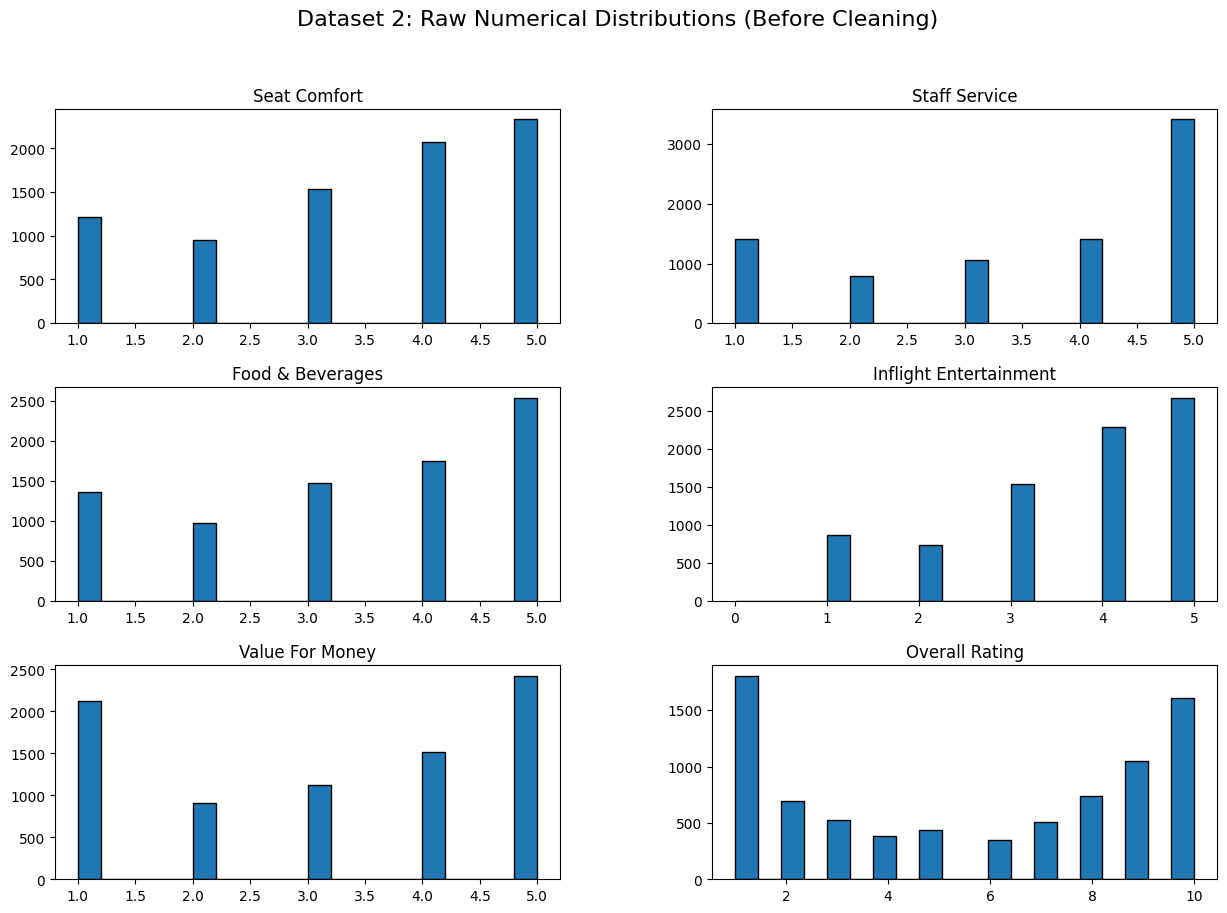

In [3]:
import matplotlib.pyplot as plt

# ==========================================
# 1. INSPECT DATASET 1: airlines_review.csv
# ==========================================
print("=== INSPECTING DATASET 1 (airlines_review.csv) ===")
try:
    df1 = pd.read_csv("airlines_review.csv")
    
    # A. Dataset info
    print("\n[1] DATASET INFO:")
    print(df1.info())  

    print("\n[2] BASIC STATS:")
    print(display(df1.describe(include='all').T))

    # B. Making plots to see what raw data looks like (not specifying columns)
    print("\n[3] PLOTTING RAW DATA...")
    df1.hist(bins=20, figsize=(15, 10), edgecolor='black', grid=False)
    plt.suptitle("Dataset 1: Raw Numerical Distributions (Before Cleaning)", fontsize=16)
    plt.show()

# Exception if file (dataset 1) does not exist
except FileNotFoundError:
    print("Error: airlines_review.csv not found.")

print("\n" + "="*60 + "\n")

# ==========================================
# 2. INSPECT DATASET 2: airlines_reviews.csv
# ==========================================
print("=== INSPECTING DATASET 2 (airlines_reviews.csv) ===")
try:
    df2 = pd.read_csv("airlines_reviews.csv")

    # A. Dataset info
    print("\n[1] DATA INFO:")
    print(df2.info()) 

    print("\n[2] BASIC STATS:")
    print(display(df2.describe(include='all').T))

    # B. Visuals
    print("\n[3] PLOTTING RAW DATA...")
    df2.hist(bins=20, figsize=(15, 10), edgecolor='black', grid=False)
    plt.suptitle("Dataset 2: Raw Numerical Distributions (Before Cleaning)", fontsize=16)
    plt.show()

# Exception if file (dataset 2) does not exist
except FileNotFoundError:
    print("Error: airlines_reviews.csv not found.")

**PHASE 2 - DATA PREPROCESSING**

**Part 1 - Cleaning for 1st Dataset (airlines_review.csv)**

Previewing 1st Dataset

In [4]:
print(df1.head())

          Airlines         Name  Location Date Published  \
0  british_airways      C Hayne      2024     2024-08-15   
1  british_airways    C Porter       2024     2024-08-12   
2  british_airways      G Jones      2024     2024-08-12   
3  british_airways  Edward King      2024     2024-08-11   
4  british_airways       N Kwok      2024     2024-08-09   

                                        Text Content       Seat Type  \
0  Not Verified | Before my flight, I was forced ...    Solo Leisure   
1  ✅ Trip Verified |   British Airways at its bes...            A350   
2  ✅ Trip Verified | An excellent flight! Despite...            A320   
3  ✅ Trip Verified | I recently traveled with Bri...            A380   
4  ✅ Trip Verified |   My family and I were booke...  Family Leisure   

   Seat Comfort  Cabin Staff Service  Food & Beverages  \
0           NaN                  NaN               NaN   
1           NaN                  NaN               NaN   
2           NaN                 

1.1 - Remove Unecessary Columns (Data Cleaning)

In [5]:
df1.drop(columns=["Name", "Seat Type", "Location"], inplace=True, errors="ignore")

1.2 - Rename Columns (Data Standardization)

In [6]:
df1.rename(columns={
    "Airlines": "airline",
    "Name": "name",  
    "Date Published": "review_date",
    "Text Content": "review_text",
    "Seat Comfort": "seat_comfort",
    "Cabin Staff Service": "staff_service",
    "Food & Beverages": "food_beverage",
    "Inflight Entertainment": "inflight_entertainment",
    "Value For Money": "value_for_money",
    "Recommended": "recommended",
    "Ground Service": "ground_service",
    "Wifi & Connectivity": "wifi_connectivity"
}, inplace=True)

print(df1.columns)

Index(['airline', 'review_date', 'review_text', 'seat_comfort',
       'staff_service', 'food_beverage', 'inflight_entertainment',
       'value_for_money', 'recommended', 'ground_service',
       'wifi_connectivity'],
      dtype='object')


1.3 - Standardizing Airline Column (Data Standardization)

In [7]:
df1["airline"] = df1["airline"].str.lower().str.replace(" ", "_").str.replace("-", "_")

print(df1["airline"].unique())

['british_airways' 'air_france' 'emirates' 'qatar_airways'
 'qantas_airways' 'singapore_airlines']


1.4 - Clean "review_text" & Extract Verification Status (Data Transformation)

In [8]:
# Extract "Trip Verified" / "Not Verified" into a new column
df1["verification"] = df1["review_text"].str.extract(r"(Trip Verified|Not Verified)", expand=False)

#  Replace values with standardized format
df1["verification"] = df1["verification"].replace({
    "Trip Verified": "verified",
    "Not Verified": "not verified"
})

# Remove the verification phrase from the original review text
df1["review_text"] = df1["review_text"].str.replace(r"(Trip Verified|Not Verified)\s*\|\s*", "", regex=True)

# Convert to string 
df1["review_text"] = df1["review_text"].astype(str)

# Remove noisy characters
df1["review_text"] = df1["review_text"].str.encode('ascii', errors='ignore').str.decode('ascii')

# Remove extra spaces
df1["review_text"] = df1["review_text"].str.strip()
df1["review_text"] = df1["review_text"].str.replace(r"\s+", " ", regex=True)

# Preview cleaned results
print(df1[["verification", "review_text"]].head())

   verification                                        review_text
0  not verified  Before my flight, I was forced by the ground s...
1      verified  British Airways at its best. Outstanding servi...
2      verified  An excellent flight! Despite this being a 4.5 ...
3      verified  I recently traveled with British Airways and h...
4      verified  My family and I were booked to leave London fo...


1.5 - Convert Date Format & Separate Columns for "review_date" column (Data Transformation)

In [9]:
# Convert review_date to datetime format
df1["review_date"] = pd.to_datetime(df1["review_date"], errors="coerce") 

# Extract year, month, day as separate numeric columns for ML
df1["review_year"] = df1["review_date"].dt.year 
df1["review_month"] = df1["review_date"].dt.month
df1["review_day"] = df1["review_date"].dt.day

# Remove review_date since it's unused
df1.drop(columns=["review_date"], inplace=True, errors="ignore")

print(df1[["review_year", "review_month", "review_day"]].head())

   review_year  review_month  review_day
0         2024             8          15
1         2024             8          12
2         2024             8          12
3         2024             8          11
4         2024             8           9


1.6 - Cleaning Categorical Data (Data Normalization)

In [10]:
# Numerical and categorical columns to handle
columns_to_clean = [
    "seat_comfort",
    "staff_service",
    "food_beverage",
    "inflight_entertainment",
    "value_for_money",
    "ground_service",
    "wifi_connectivity",
    "recommended"          # boolean
]

# Replace blank/whitespace strings with NaN and round
for col in columns_to_clean:
    if col != "recommended":
        df1[col] = df1[col].replace(r'^\s*$', np.nan, regex=True)
        df1[col] = pd.to_numeric(df1[col], errors='coerce')
        df1[col] = df1[col].round(2)

# To forcefully show 2 digits in terminal
pd.options.display.float_format = '{:.2f}'.format

# Convert True/False to "yes"/"no" for consistency
df1["recommended"] = df1["recommended"].apply(lambda x: "yes" if x == True else "no")

print(df1[columns_to_clean].head())

   seat_comfort  staff_service  food_beverage  inflight_entertainment  \
0           NaN            NaN            NaN                    1.00   
1           NaN            NaN            NaN                     NaN   
2           NaN            NaN            NaN                     NaN   
3           NaN            NaN            NaN                     NaN   
4           NaN            NaN            NaN                    1.00   

   value_for_money  ground_service  wifi_connectivity recommended  
0             1.00             NaN                NaN          no  
1             5.00             NaN                NaN          no  
2             3.00             NaN                NaN          no  
3             3.00             NaN                NaN          no  
4             1.00             NaN                NaN          no  


1.7 - Exporting Cleaned 1st Dataset

In [11]:
df1.to_csv("cleaned_data1.csv", index=False, na_rep="NaN")

**Part 2 - Cleaning for 2nd Dataset (airlines_reviews.csv)**

Preview 2nd Dataset

In [12]:
print(df2.head())

                                  Title              Name Review Date  \
0                    Flight was amazing  Alison Soetantyo    3/1/2024   
1  seats on this aircraft are dreadful      Robert Watson   2/21/2024   
2          Food was plentiful and tasty             S Han   2/20/2024   
3          “how much food was available          D Laynes   2/19/2024   
4       “service was consistently good”         A Othman    2/19/2024   

              Airline Verified  \
0  Singapore Airlines     TRUE   
1  Singapore Airlines     TRUE   
2  Singapore Airlines     TRUE   
3  Singapore Airlines     TRUE   
4  Singapore Airlines     TRUE   

                                             Reviews Type of Traveller  \
0    Flight was amazing. The crew onboard this fl...      Solo Leisure   
1    Booking an emergency exit seat still meant h...      Solo Leisure   
2    Excellent performance on all fronts. I would...    Family Leisure   
3   Pretty comfortable flight considering I was f...      So

2.1 - Remove Unnecessary Columns (Data Cleaning)

In [13]:
df2.drop(columns=["Title", "Name", "Type of Traveller", "Route", "Class", "Month Flown"], inplace=True, errors="ignore")

2.2 - Rename Columns (Data Standardization)

In [14]:
df2.rename(columns={
    "Review Date": "review_date",
    "Airline": "airline",
    "Verified": "verification",
    "Reviews": "review_text",
    "Seat Comfort": "seat_comfort",
    "Staff Service": "staff_service",
    "Food & Beverages": "food_beverage",
    "Inflight Entertainment": "inflight_entertainment",
    "Value For Money": "value_for_money",
    "Overall Rating": "overall_rating",
    "Recommended": "recommended"
}, inplace=True)


print(df2.columns)

Index(['review_date', 'airline', 'verification', 'review_text', 'seat_comfort',
       'staff_service', 'food_beverage', 'inflight_entertainment',
       'value_for_money', 'overall_rating', 'recommended'],
      dtype='object')


2.3 - Standardizing Airlines Column (Data Standardization)

In [15]:
# To ensure that it is in string format by removing extra whitespaces
df2["airline"] = df2["airline"].str.lower().str.replace(" ", "_").str.replace("-", "_")

print(df2["airline"].head())

0    singapore_airlines
1    singapore_airlines
2    singapore_airlines
3    singapore_airlines
4    singapore_airlines
Name: airline, dtype: object


2.4 - Convert Date Format & Separate Columns for "review_date" column (Data Transformation)

In [16]:
# Convert review_date to datetime format
df2["review_date"] = pd.to_datetime(df2["review_date"], errors="coerce") 

# Extract year, month, day as separate columns
df2["review_year"] = df2["review_date"].dt.year 
df2["review_month"] = df2["review_date"].dt.month
df2["review_day"] = df2["review_date"].dt.day

# Remove review_date column since not needed
df2.drop(columns=["review_date", ""], inplace=True, errors="ignore") 

print(df2[["review_year", "review_month", "review_day"]].head())

   review_year  review_month  review_day
0         2024             3           1
1         2024             2          21
2         2024             2          20
3         2024             2          19
4         2024             2          19


2.5 - Standardize Verified Column

In [17]:
# To ensure verification text is lowercase
df2["verification"] = df2["verification"].astype(str).str.strip().str.lower()

# Set "true = verified" & "false = not verified"
df2["verification"] = df2["verification"].apply(lambda x: "verified" if x == "true" else "not verified")

print(df2[["verification"]].head())

  verification
0     verified
1     verified
2     verified
3     verified
4     verified


2.6 - Clean review_text (Text Cleaning)

In [18]:
# Convert to string 
df2["review_text"] = df2["review_text"].astype(str)

# Remove noisy characters
df2["review_text"] = df2["review_text"].str.encode('ascii', errors='ignore').str.decode('ascii')

# Remove unnecessary spaces
df2["review_text"] = df2["review_text"].str.strip()
df2["review_text"] = df2["review_text"].str.replace(r"\s+", " ", regex=True)

print(df2[["review_text"]].head())

                                         review_text
0  Flight was amazing. The crew onboard this flig...
1  Booking an emergency exit seat still meant hug...
2  Excellent performance on all fronts. I would d...
3  Pretty comfortable flight considering I was fl...
4  The service was consistently good from start t...


2.7 - Handling Categorical Data (Data Normalization & Transformation)

In [19]:
# Define the rating columns and their original ranges
rating_columns_df2 = {
    "seat_comfort": "1-5",
    "staff_service": "1-5",
    "food_beverage": "1-5",
    "inflight_entertainment": "0-5",  # already in correct scale
    "value_for_money": "1-10",
    "overall_rating": "1-10"
}

# Apply transformations
for col, scale in rating_columns_df2.items():
    if col in df2.columns:
        if scale == "1-5":
            # Convert 1–5 to 0–5 scale
            df2[col] = df2[col].apply(lambda x: round((x - 1) * (5 / 4), 2))
        elif scale == "1-10":
            # Convert 1–10 to 0–5 scale
            df2[col] = df2[col].apply(lambda x: round((x - 1) * (5 / 9), 2))
        # No change needed for "0-5" scale
        df2[col] = df2[col].round(2)  # Round to 2 decimal places

print(df2[["seat_comfort", "staff_service", "food_beverage", "inflight_entertainment", "value_for_money", "overall_rating"]].head())

   seat_comfort  staff_service  food_beverage  inflight_entertainment  \
0          3.75           3.75           3.75                       4   
1          5.00           2.50           3.75                       4   
2          0.00           5.00           1.25                       1   
3          5.00           5.00           5.00                       5   
4          5.00           5.00           5.00                       5   

   value_for_money  overall_rating  
0             1.67            4.44  
1             0.00            1.11  
2             2.22            5.00  
3             2.22            5.00  
4             2.22            5.00  


2.8 - Normalization for Recommended Columns

In [20]:
# To ensure lower case 
df2["recommended"] = df2["recommended"].str.strip().str.lower()

print(df2[["recommended"]].head())

  recommended
0         yes
1          no
2         yes
3         yes
4         yes


2.9 - Export Cleaned 2nd Dataset

In [21]:
df2.to_csv("cleaned_data2.csv", index=False, na_rep="NaN")

**Part 3 - Combining Datasets**

In [22]:
# Load both cleaned datasets
df1 = pd.read_csv("cleaned_data1.csv")
df2 = pd.read_csv("cleaned_data2.csv")

# Combine datasets
combined_df = pd.concat([df1, df2], ignore_index=True)

# reorder columns
column_order = [
    'review_year', 'review_month', 'review_day',
    'airline', 'review_text',
    'seat_comfort', 'staff_service', 'food_beverage',
    'inflight_entertainment', 'ground_service', 'wifi_connectivity',
    'value_for_money', 'recommended', 'verification',
    'overall_rating'
]
combined_df = combined_df[column_order]

**Part 4 - Further Text Preprocessing for "review_text" column**

4.1 - Ensuring imports 

In [23]:
# Ensuring imports
import pandas as pd
import re
import string
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download stopwords (to ensure)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


# English stopword list
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


4.2 - Performing Basic Cleaning

In [24]:
review_col = "review_text"

def preprocess_text(text):
    if pd.isnull(text):
        text = ""
    
    # 1. Lowercase
    text = str(text).lower()
    
    # 2. Replace common separators with space
    text = re.sub(r'[\r\n\t]+', ' ', text)
    
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 4. Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. Tokenize by splitting
    words = text.split()
    
    # 6. Remove stopwords
    words = [w for w in words if w not in stop_words]
    
    # 7. Rejoin words
    return " ".join(words)

# Apply to the dataframe
combined_df['cleaned_review_text'] = combined_df[review_col].apply(preprocess_text)

4.3 - Regex (Regular Expressions)

In [25]:
def replace_patterns(text):
    if not text:
        return ""
    
# 1. convert time/duration/date patterns to placeholder "time_duration"
    # Time
    text = re.sub(r'\b\d{1,2}[:\.\-]\d{2}(am|pm)?\b', ' time_duration ', text)   # 06:30, 06.30
    text = re.sub(r'\b\d{1,4}(am|pm)\b', ' time_duration ', text)                # 0630am, 0130pm, 9am
    text = re.sub(r'\b\d{1,2}h\d{1,2}m?\b', ' time_duration ', text)             # 07h25, 4h30
    text = re.sub(r'\b\d+(h|hr|hrs|hour|hours|min|mins|minute|minutes|month|months|yr|yrs|year|years)\b', ' time_duration ', text) # 3months, 2yr
    
    # Date
    # 10th Oct, Mar 2024, 25 Jul
    text = re.sub(r'\b(?:\d{1,2}(?:st|nd|rd|th)?[-/\s]?)?(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*[-]?\d{0,4}\b', ' date_value ', text) 
    text = re.sub(r'\b\d{1,2}[-/\.]\d{1,2}[-/\.]\d{2,4}\b', ' date_value ', text)  # 09/02/2020
    
# 2. Convert price/currency to placeholder "price_value"
    # Price before currency code (100usd, 200eur)
    text = re.sub(r'\b\d{1,6}(usd|us|eur|gbp|chf|cad|aud|inr|idr|myr|php|hkd|sgd|try|krw|jpy|¥|€|\$|rs|rmb|cny)\w*\b', ' price_value ', text) 

    # Currency symbol before number (#$100)
    text = re.sub(r'\b\$\s?\d{1,6}\b', ' price_value ', text) #$100
    
# 3. Convert units (weight/length/volume/height) to placeholder "weight_value" 
    # Units
    text = re.sub(r'\b\d+(kg|kgs|g|gram|grams|lb|lbs|ft|feet|foot|inch|inches|cm|mm|l|litre|litres|ml|mls)\w*\b', ' weight_value ', text)

    # Specifically "5ft10", "6ft2"
    text = re.sub(r'\b\dft\d{1,2}\b', ' weight_value ', text)
    
# 4. Convert seat numbers (with 1-3 letters) to placeholder "seat_number"
    text = re.sub(r'\b\d{1,3}[a-zA-Z]{1,3}\b', ' seat_number ', text)
    
# 5. Convert ordinal numbers to placeholder "number_ordinal"
    text = re.sub(r'\b\d+(st|nd|rd|th)\b', ' number_ordinal ', text)
    
# 6. Convert aircraft models (many variants) to placeholder "aircraft_model"
    # Aircraft models in format like a320, a320-200, a321neo, b737-800, 737max, 777-300er, 787-9
    text = re.sub(r'\b(?:a|b)\d{2,4}(?:[- ]?(?:neo|ulr|xlr|lr|er|max|s)?)?\b', ' aircraft_model ', text)

    # Combined variants like a380b777 or 777a330 
    text = re.sub(r'\b(?:a|b)\d{2,4}(?:[a-z]{1,6}\d{0,4})+\b', ' aircraft_model ', text)
    
# 7. Convert flight/tail/registration codes to placeholder "flight_code"
    # common registration prefixes: a6, 9v, vh, ja, hs, oe, tc, g-, hb
    text = re.sub(r'\b(?:[a-z]{1,3}-?\d{0,4}|\d+[a-z]{2,})\b', lambda m: ' flight_code ' if re.search(r'\d', m.group(0)) and re.search(r'[a-zA-Z]', m.group(0)) else m.group(0), text)
    
    # explicit generic flight numbers with 2-letter airline code + digits (QR578)
    text = re.sub(r'\b[a-zA-Z]{2}\d{2,4}\b', ' flight_code ', text)
    
# 8. Remove any leftover long numeric-only tokens
    text = re.sub(r'\b\d{2,}\b', ' ', text)
    
# 9. Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

combined_df['cleaned_review_text'] = combined_df['cleaned_review_text'].apply(replace_patterns)


4.4 - Convert multi-word entities to single tokens

In [26]:
def preserve_entities(text):
    if not isinstance(text, str):  # handle None/NaN
        text = ""
    text = text.lower()  # ensure lowercase for matching
    
    replacements = {
        "hong kong": "hong_kong",
        "new york": "new_york",
        "kuala lumpur": "kuala_lumpur",
        "london heathrow": "london_heathrow",
        "charles de gaulle": "charles_de_gaulle",
        "british airways": "british_airways",
        "singapore airlines": "singapore_airlines",
        "qatar airways": "qatar_airways",
        "emirates airlines": "emirates_airlines"
    }
    
    for phrase, token in replacements.items():
        text = text.replace(phrase, token)
    return text

combined_df['cleaned_review_text'] = combined_df['cleaned_review_text'].apply(preserve_entities)

4.5 - Expanding shortforms

In [27]:
# Cell 5 - shortform expansion
shortform_dict = {
    'svc': 'service',
    'dep': 'departure',
    'arr': 'arrival',
    'bkk': 'bangkok',
    'sin': 'singapore',
    'kul': 'kuala_lumpur',
    'hkg': 'hong_kong',
    'lhr': 'london_heathrow',
    'cdg': 'charles_de_gaulle',
    'fco': 'rome',
    'zrh': 'zurich',
    'jfk': 'new_york',
    'lgw': 'london_gatwick',
    'us': 'united_states',
    'uk': 'united_kingdom',
    'ba': 'british_airways',
    'ek': 'emirates',
    'sq': 'singapore_airlines',
    'qr': 'qatar_airways',
    'cx': 'cathay_pacific'
}

def expand_shortforms(text):
    if not isinstance(text, str):  # handle None/NaN
        text = ""
    words = []
    for w in text.split():
        replacement = shortform_dict.get(w.lower(), w)  # lowercase for consistent matching
        words.append(replacement)
    return " ".join(words)

combined_df['cleaned_review_text'] = combined_df['cleaned_review_text'].apply(expand_shortforms)


4.6 - Lemmatization & Remove Stop Words

In [28]:
def lemmatize_text_final(text):
    words = text.split()
    lemmas = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(lemmas)

def remove_stopwords(text):
    tokens = text.split()
    filtered = [w for w in tokens if w not in stop_words]
    return " ".join(filtered)

combined_df['cleaned_review_text'] = combined_df['cleaned_review_text'].apply(remove_stopwords)

4.7 - Final Cleanup

In [29]:
def final_cleanup(text):
    tokens = []
    for t in text.split():
        # keep our placeholders and words with only letters/underscores
        if t in {"time_duration","price_value","weight_value","seat_number","aircraft_model","flight_code","date_value","number_ordinal","year_value"}:
            tokens.append(t)
        elif re.fullmatch(r'[a-z_]+', t):  # only lowercase letters and underscore
            tokens.append(t)
        # otherwise drop the token (it contained digits or weird chars)
    return " ".join(tokens)

combined_df['cleaned_review_text'] = combined_df['cleaned_review_text'].apply(final_cleanup)

# Top 50 to inspect
all_words = " ".join(combined_df['cleaned_review_text']).split()
word_counts = Counter(all_words)
print("Top 50 after final cleanup:")
print(word_counts.most_common(50))



Top 50 after final cleanup:
[('flight', 37681), ('service', 17509), ('food', 12643), ('time', 12053), ('good', 11820), ('seat', 11570), ('crew', 10882), ('date_value', 10002), ('class', 9977), ('seats', 9713), ('staff', 9622), ('cabin', 9328), ('business', 8774), ('one', 8747), ('would', 7891), ('british_airways', 7330), ('emirates', 7155), ('economy', 7150), ('flights', 7078), ('airline', 7004), ('united_states', 6933), ('hours', 6672), ('first', 6564), ('get', 6480), ('via', 6267), ('airport', 6240), ('experience', 6012), ('even', 5617), ('passengers', 5501), ('aircraft_model', 5449), ('back', 5439), ('dubai', 5406), ('meal', 5387), ('doha', 5297), ('plane', 5233), ('boarding', 5208), ('could', 5201), ('airlines', 5194), ('great', 5147), ('lounge', 4763), ('air', 4733), ('comfortable', 4636), ('return', 4507), ('fly', 4491), ('singapore', 4484), ('entertainment', 4323), ('aircraft', 4320), ('hour', 4314), ('check', 4305), ('told', 4288)]


**Part 5 - Export Cleaned Overall Dataset**

In [30]:
combined_df.to_csv("combined_reviews.csv", index=False, na_rep="NaN")

**PHASE 3 - DATA UNDERSTANDING (AFTER PREPROCESSING)**

1. Preview Dataset

In [31]:
# Load dataset
df = pd.read_csv("combined_reviews.csv")

# Preview data
df.info()
df.describe(include='all')  # includes categorical columns too

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21690 entries, 0 to 21689
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   review_year             21690 non-null  int64  
 1   review_month            21690 non-null  int64  
 2   review_day              21690 non-null  int64  
 3   airline                 21690 non-null  object 
 4   review_text             21690 non-null  object 
 5   seat_comfort            11223 non-null  float64
 6   staff_service           11224 non-null  float64
 7   food_beverage           11254 non-null  float64
 8   inflight_entertainment  14849 non-null  float64
 9   ground_service          9610 non-null   float64
 10  wifi_connectivity       7154 non-null   float64
 11  value_for_money         19004 non-null  float64
 12  recommended             21690 non-null  object 
 13  verification            14295 non-null  object 
 14  overall_rating          8100 non-null 

,review_year,review_month,review_day,airline,review_text,seat_comfort,staff_service,food_beverage,inflight_entertainment,ground_service,wifi_connectivity,value_for_money,recommended,verification,overall_rating,cleaned_review_text
count,21690.00,21690.00,21690.00,21690,21690,11223.00,11224.00,11254.00,14849.00,9610.00,7154.00,19004.00,21690,14295,8100.00,21690
unique,NaN,NaN,NaN,12,17996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,17995
top,NaN,NaN,NaN,qatar_airways,Unforgettable experience flying with Emirates ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,verified,NaN,unforgettable experience flying emirates singa...
freq,NaN,NaN,NaN,4094,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16943,11447,NaN,4
mean,2018.23,6.51,15.73,NaN,NaN,3.15,3.35,3.10,3.37,3.52,3.53,2.35,NaN,NaN,2.57,NaN
std,2.95,3.49,8.86,NaN,NaN,1.64,1.80,1.72,1.42,1.41,1.53,1.60,NaN,NaN,1.96,NaN
min,2011.00,1.00,1.00,NaN,NaN,0.00,0.00,0.00,0.00,0.00,1.00,0.00,NaN,NaN,0.00,NaN
25%,2016.00,3.00,8.00,NaN,NaN,2.00,2.00,1.25,2.00,3.00,2.00,1.00,NaN,NaN,0.56,NaN
50%,2018.00,7.00,16.00,NaN,NaN,3.75,3.75,3.75,4.00,4.00,4.00,2.22,NaN,NaN,2.78,NaN
75%,2020.00,10.00,23.00,NaN,NaN,5.00,5.00,5.00,5.00,5.00,5.00,4.00,NaN,NaN,4.44,NaN


2. Plotting Histograms

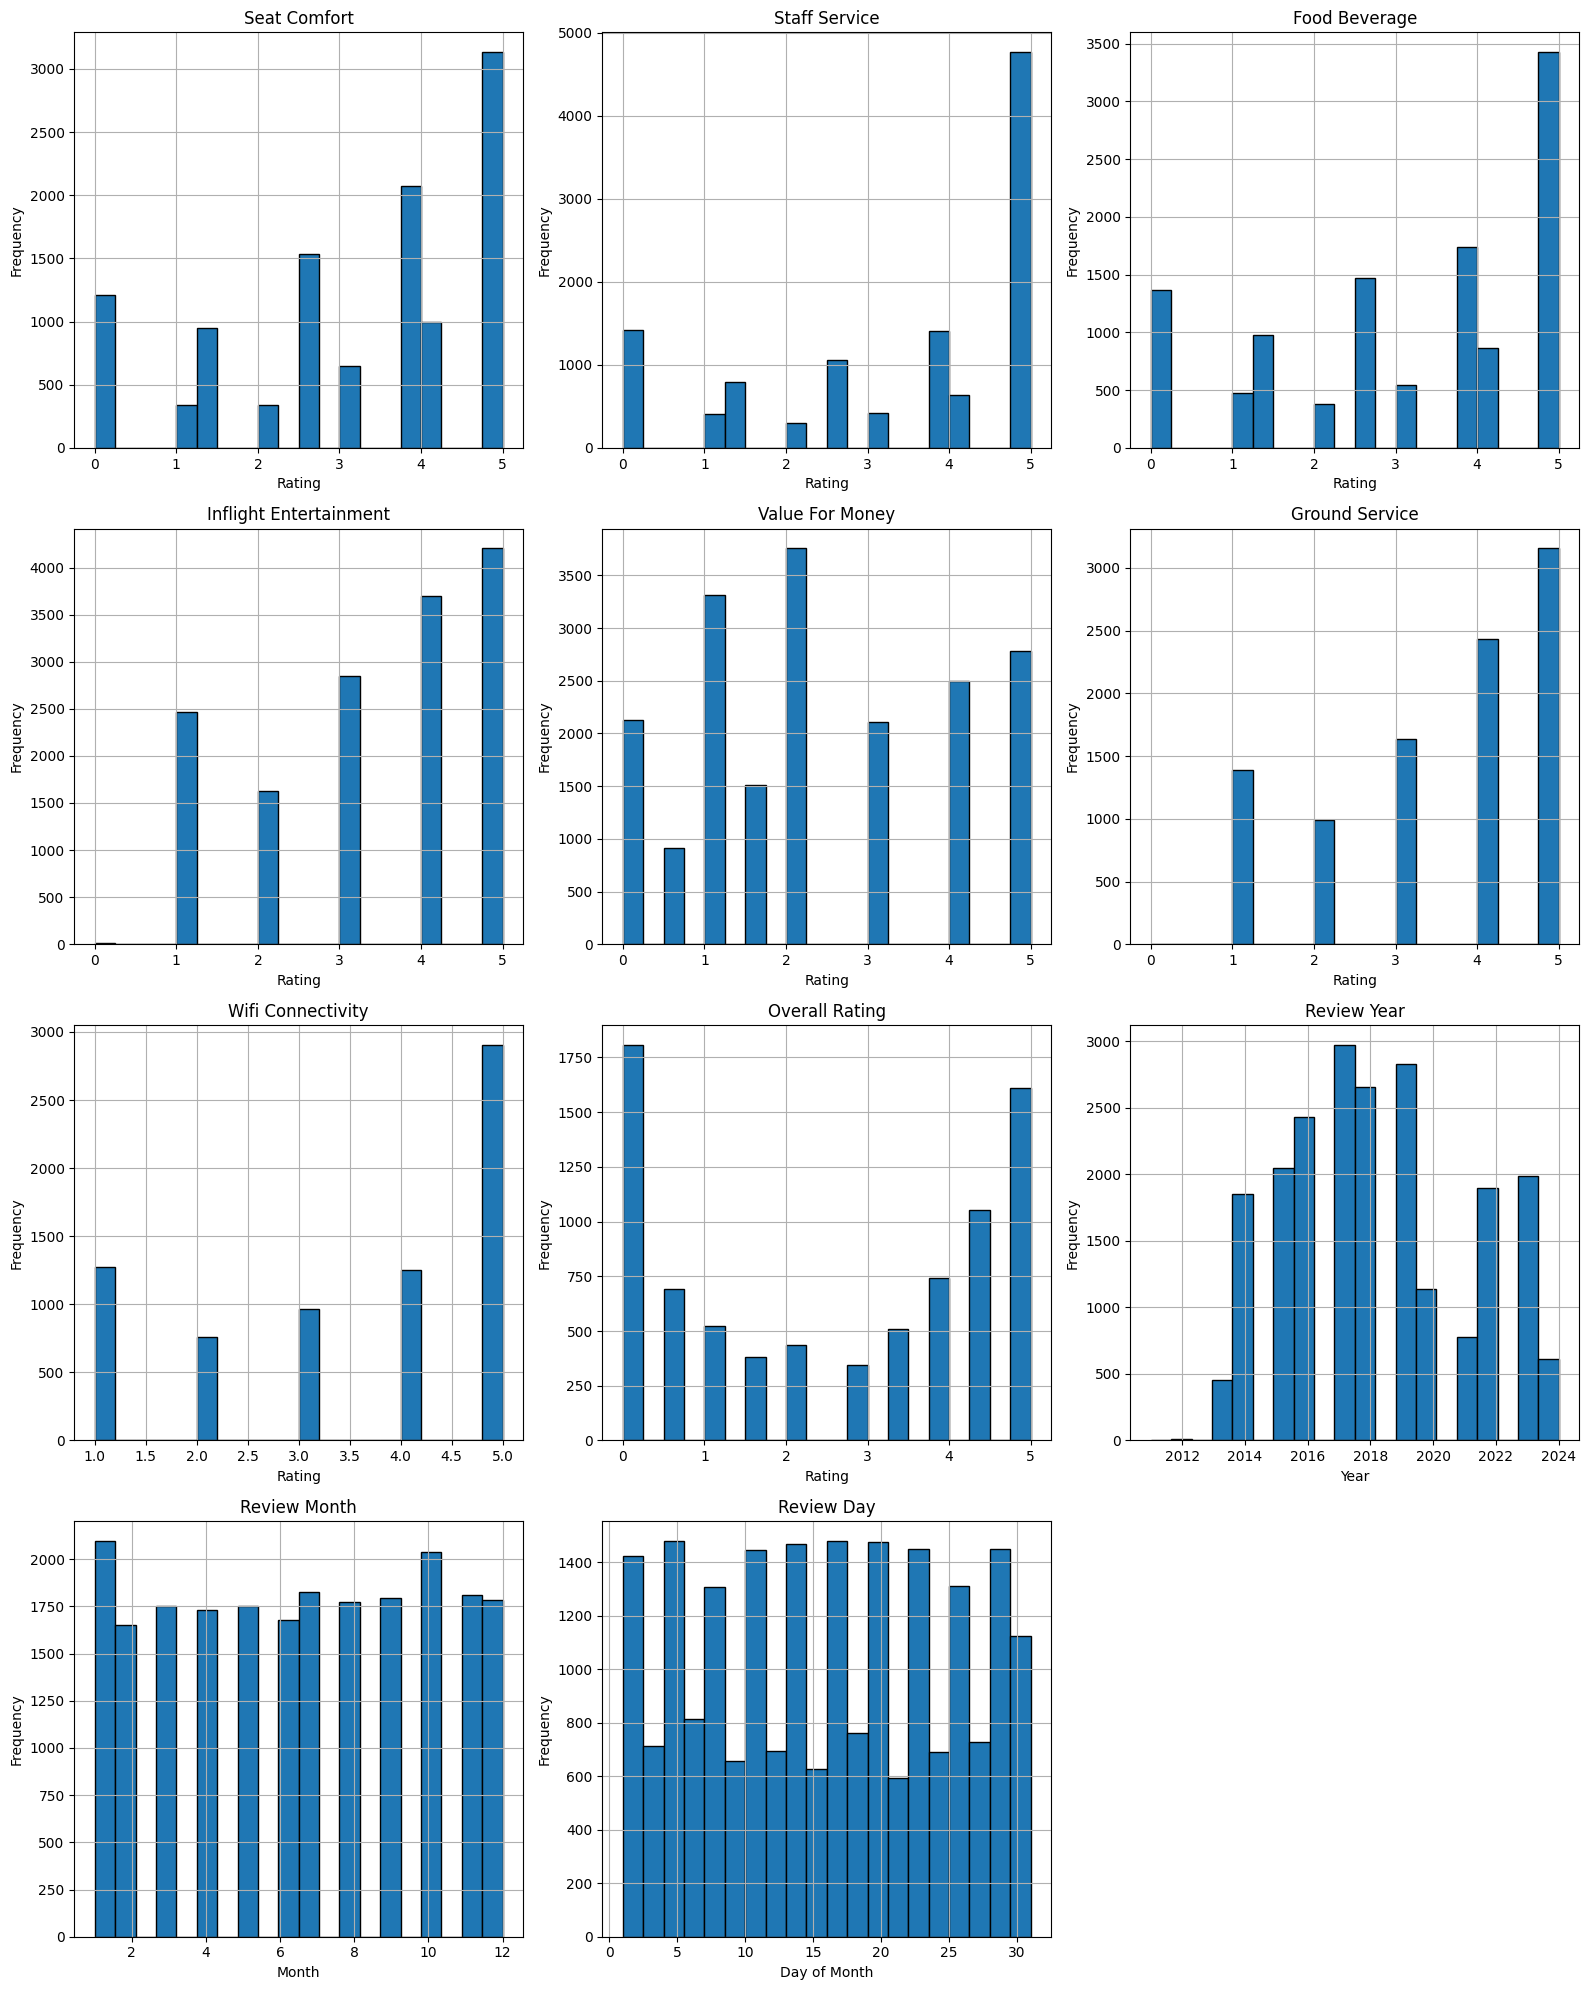

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('combined_reviews.csv')

# Define the list of numerical columns for histogram plotting
numerical_cols = [
    'seat_comfort', 'staff_service', 'food_beverage',
    'inflight_entertainment', 'value_for_money', 'ground_service',
    'wifi_connectivity', 'overall_rating', 'review_year',
    'review_month', 'review_day'
]

# Set plot style and figure size
plt.style.use('default')
plt.figure(figsize=(16, 20))

# Plot each histogram
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)

    df[col].hist(bins=20, edgecolor='black')

    plt.title(col.replace('_', ' ').title())

    # Custom X-axis labels
    if col == 'review_year':
        plt.xlabel('Year')
    elif col == 'review_month':
        plt.xlabel('Month')
    elif col == 'review_day':
        plt.xlabel('Day of Month')
    else:
        plt.xlabel('Rating')

    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


**PHASE 4 - TEXT ANALYSIS (ANALYSING PREPROCESSED TEXT COLUMN)**

1. Word Cloud

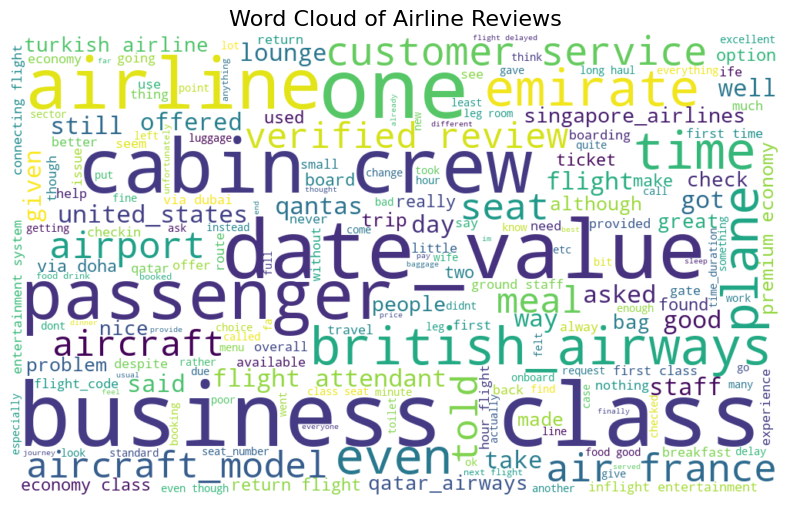

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cleaned_review_text'])
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Airline Reviews", fontsize=16)
plt.show()


2. Word Count Frequencies

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


              Word  Frequency
0           flight      37681
1          service      17509
2             food      12643
3             time      12053
4             good      11820
5             seat      11570
6             crew      10882
7        datevalue      10002
8            class       9977
9            seats       9713
10           staff       9622
11           cabin       9328
12        business       8774
13             one       8747
14           would       7891
15  britishairways       7330
16        emirates       7155
17         economy       7150
18         flights       7078
19         airline       7004


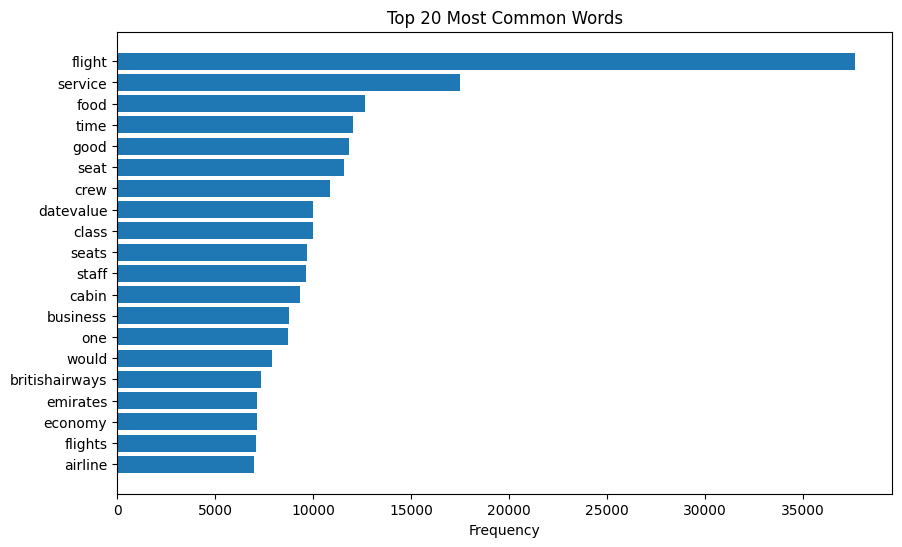

In [ ]:
# Combine all reviews into one big string
text = " ".join(df['cleaned_review_text'].dropna()).lower()

# Remove punctuation and numbers
text = re.sub(r'[^a-z\s]', '', text)

# Split into word count frequencies
words = text.split()
word_counts = Counter(words)

# Download stopwords 
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Filter them out
filtered_words = [word for word in words if word not in stop_words]

# Count 
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

print(common_words)

# Plot
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10,6))
plt.barh(words, counts)
plt.gca().invert_yaxis()
plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.show()

3. Basic Descriptive Statistics

In [35]:
# Make sure df has the review_text column
df['cleaned_review_text'] = df['cleaned_review_text'].fillna('')  # replace NaN with empty string

# Word count per review
df['word_count'] = df['cleaned_review_text'].apply(lambda x: len(x.split()))

# Character count (excluding spaces)
df['char_count'] = df['cleaned_review_text'].apply(lambda x: len(re.sub(r'\s+', '', x)))

# Average word length (avoid division by zero)
df['avg_word_length'] = df.apply(
    lambda row: row['char_count'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1
)

# Sentence count (rough estimate using punctuation)
df['sentence_count'] = df['cleaned_review_text'].apply(lambda x: len(re.split(r'[.!?]+', x)) - 1)

# Summary statistics
text_stats = {
    'Average Word Count': df['word_count'].mean(),
    'Average Sentence Count': df['sentence_count'].mean(),
    'Average Word Length': df['avg_word_length'].mean(),
    'Max Word Count': df['word_count'].max(),
    'Min Word Count': df['word_count'].min(),
}

for k, v in text_stats.items():
    print(f"{k}: {v:.2f}")


Average Word Count: 76.04
Average Sentence Count: 0.00
Average Word Length: 6.28
Max Word Count: 641.00
Min Word Count: 8.00


4. N Gram Analysis

🔹 Top 20 Most Common Bigrams:
                        Bigram  Frequency
68621           business class       6324
70427               cabin crew       4281
123723        customer service       2652
9878                air france       2609
524491         verified review       2182
369722         premium economy       1599
508834        turkish airlines       1592
158416           economy class       1501
192593       flight attendants       1370
251717  inflight entertainment       1351
407899           return flight       1209
223667            ground staff       1120
239680             hour flight       1092
109684       connecting flight       1046
276533                leg room        893
287590               long haul        889
202658               food good        863
192592        flight attendant        808
193215          flight delayed        779
428386       seats comfortable        727


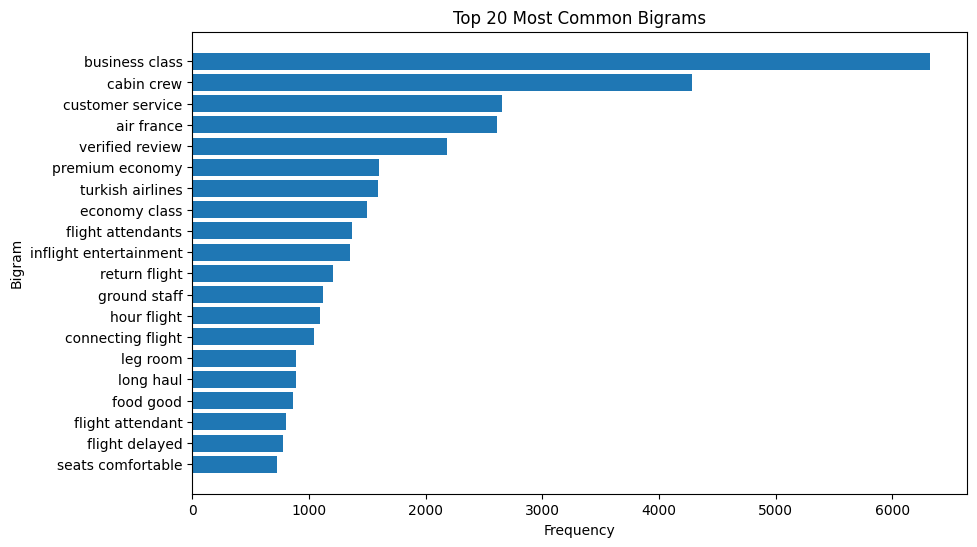


🔹 Top 20 Most Common Trigrams:
                                Trigram  Frequency
124346             business class seats        356
124341              business class seat        276
124047            business class lounge        257
124184        business class passengers        244
128669              cabin crew friendly        234
537238                 long haul flight        215
953493             verified review flew        207
582514         missed connecting flight        173
123569             business class cabin        170
353006             flight delayed hours        166
124242           business class product        161
537239                long haul flights        160
350406                flight cabin crew        149
377207                   fly air france        149
798162               service cabin crew        139
447679                      ho chi minh        135
123822            business class flight        131
953573  verified review london_heathrow        124

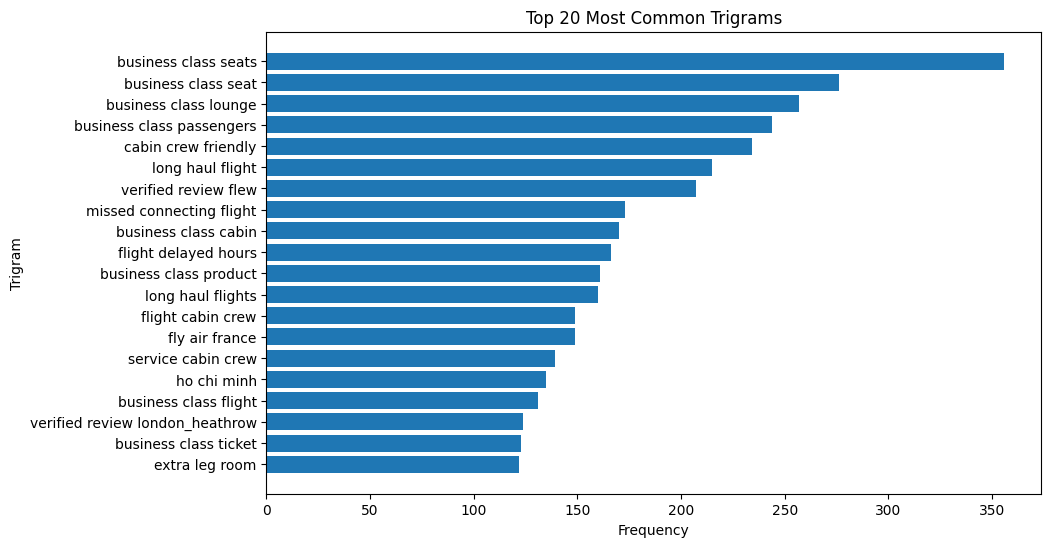

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigrams (2-word phrases)
vectorizer_bigram = CountVectorizer(ngram_range=(2,2), stop_words='english')
X2 = vectorizer_bigram.fit_transform(df['cleaned_review_text'].dropna())

# Frequencies of each bigram word
bigrams = pd.DataFrame(
    zip(vectorizer_bigram.get_feature_names_out(), X2.sum(axis=0).tolist()[0]),
    columns=['Bigram', 'Frequency']
).sort_values(by='Frequency', ascending=False).head(20)

print("🔹 Top 20 Most Common Bigrams:")
print(bigrams)

# Bigram Plots
plt.figure(figsize=(10,6))
plt.barh(bigrams['Bigram'], bigrams['Frequency'])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Common Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()


# Trigrams (3-word phrases) 
vectorizer_trigram = CountVectorizer(ngram_range=(3,3), stop_words='english')
X3 = vectorizer_trigram.fit_transform(df['cleaned_review_text'].dropna())

# Frequencies of each trigram word
trigrams = pd.DataFrame(
    zip(vectorizer_trigram.get_feature_names_out(), X3.sum(axis=0).tolist()[0]),
    columns=['Trigram', 'Frequency']
).sort_values(by='Frequency', ascending=False).head(20)

print("\n🔹 Top 20 Most Common Trigrams:")
print(trigrams)

# Tigram Plots
plt.figure(figsize=(10,6))
plt.barh(trigrams['Trigram'], trigrams['Frequency'])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Common Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.show()